In [1]:
import bottleneck as bn
import matplotlib
import matplotlib.dates as mdates
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import scienceplots
import scipy
import scipy.signal
import scipy.special
import scipy.stats
import sklearn.decomposition
import astropy.io
import datetime
import astropy.time
import pandas as pd

from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.style.use(['science', 'nature', 'notebook', 'grid', 'high-vis'])

figsize_short = (8, 4)
figsize_normal = (8, 6)
figsize_tall = (8, 8)
plt.rcParams['figure.figsize'] = figsize_short
plt.rcParams['axes.labelpad'] = 6.0
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.framealpha'] = 0.8
plt.rcParams['legend.edgecolor'] = 'none'


title_font = {'fontsize': 16, 'weight': 'bold', 'style': 'italic'}
path_effect = [pe.withStroke(linewidth=2.0, foreground="k")]

read_path = 'docs/Data/'
save_path = 'docs/Figure/'

perula_df = pd.read_csv(read_path + 'matlab_perula.txt', header = None, sep = '\s+')
matlab_perula = matplotlib.colors.LinearSegmentedColormap.from_list('matlab_perula', np.array(perula_df))

jet_df = pd.read_csv(read_path + 'matlab_jet.txt', header = None, sep = '\s+')
matlab_jet = matplotlib.colors.LinearSegmentedColormap.from_list('matlab_jet', np.array(jet_df))

%matplotlib ipympl

<>:41: SyntaxWarning: invalid escape sequence '\s'
<>:44: SyntaxWarning: invalid escape sequence '\s'
<>:41: SyntaxWarning: invalid escape sequence '\s'
<>:44: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_874/3118345031.py:41: SyntaxWarning: invalid escape sequence '\s'
  perula_df = pd.read_csv(read_path + 'matlab_perula.txt', header = None, sep = '\s+')
/tmp/ipykernel_874/3118345031.py:44: SyntaxWarning: invalid escape sequence '\s'
  jet_df = pd.read_csv(read_path + 'matlab_jet.txt', header = None, sep = '\s+')


/tmp/ipykernel_11326/3769427883.py:15: RuntimeWarning: divide by zero encountered in log10
  ax2.plot(freq, 10 * np.log10(psd), label='Power Spectral Density', color='C0')


0.9926862931925485
0.9543918843196101


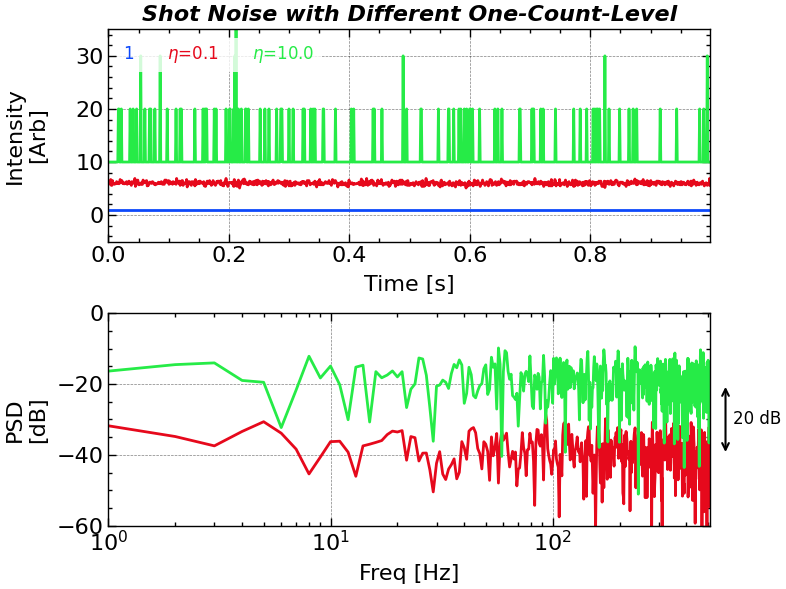

In [234]:
plt.close()
N = 2 ** 10

t = np.linspace(0, 1, N, endpoint=False)
dt = t[1] - t[0]
fs = 1 / dt
m = 0.3
sig = (1 + m * np.sin(20 * np.pi * t))
sig = 1 + 0 * t
plt.figure(figsize=figsize_normal)
ax1 = plt.subplot(2, 1, 1)
ax2 = plt.subplot(2, 1, 2)
ax1.plot(t, sig, label='1', color='C0')
freq, psd = scipy.signal.welch(sig, fs=fs, nperseg=N, window='hann')
ax2.plot(freq, 10 * np.log10(psd), label='Power Spectral Density', color='C0')

sig[sig < 0] = 0
for i, DETECTION_EFFICIENCY in enumerate([.1, 10.0, ][::-1]):
    sig_digitized = np.random.poisson(sig * DETECTION_EFFICIENCY) / DETECTION_EFFICIENCY
    ax1.plot(t, sig_digitized + (i + 1) * 5, linestyle = '-', label = r'$\eta$=' + f'{1/DETECTION_EFFICIENCY}')

    freq, psd = scipy.signal.welch(sig_digitized, fs=fs, nperseg=N, window='hann')
    ax2.plot(freq, 10 * np.log10(psd), linestyle = '-', label = f'{DETECTION_EFFICIENCY}')
    print(np.mean(psd) / (2 / DETECTION_EFFICIENCY / fs))
ax1.set_title('Shot Noise with Different One-Count-Level', **title_font)

# ax2.loglog()
ax2.set_xscale('log')
ax2.set_ylim(-60, 0)
ax1.set_ylim(-5, 35)
# ax2.set_ylim(1e-8, 1e-1)

ax1.legend(loc = 'upper left', ncol = 5, labelcolor="linecolor", handlelength = 0, handletextpad = 0, prop = {'weight': 'normal', 'size' : 12})
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Intensity\n[Arb]')
ax2.set_xlabel('Freq [Hz]')
# ax2.set_ylabel('PSD\n[Arb$^2$/Hz]')
ax2.set_ylabel('PSD\n[dB]')
# ax2.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, numticks=50))
# ax2.yaxis.set_minor_formatter(ticker.NullFormatter())
ax1.autoscale(enable=True, axis='x', tight=True)
ax2.autoscale(enable=True, axis='x', tight=True)

ax1.yaxis.set_label_coords(-0.1, 0.5)
ax2.yaxis.set_label_coords(-0.1, 0.5)

ax2.text(650, -30, '20 dB', fontsize=12, color='k', va = 'center')
ax2.annotate('', (600, -40), (600, -20), arrowprops=dict(arrowstyle='<->', lw=1.5), fontsize=12, color='k', ha='center', annotation_clip=False)

plt.tight_layout()

plt.savefig(save_path + 'figure_shot_noise' + '.png', bbox_inches='tight', dpi=300)

plt.show()

<>:13: SyntaxWarning: invalid escape sequence '\p'
<>:13: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_11326/2708664983.py:13: SyntaxWarning: invalid escape sequence '\p'
  ax1.plot(t, sig, label='sin(20$\pi$t) + 3t', color='C0')


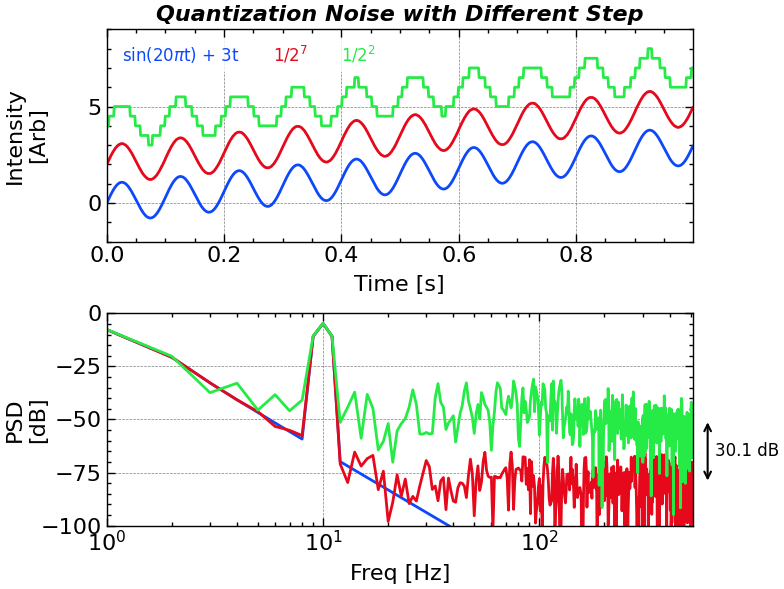

In [233]:
plt.close()
N = 2 ** 10

t = np.linspace(0, 1, N, endpoint=False)
dt = t[1] - t[0]
fs = 1 / dt
sig = np.sin(2 * np.pi * 10 * t) + 3 * t
# sig = t

plt.figure(figsize=figsize_normal)
ax1 = plt.subplot(2, 1, 1)
ax2 = plt.subplot(2, 1, 2)
ax1.plot(t, sig, label='sin(20$\pi$t) + 3t', color='C0')
freq, psd = scipy.signal.welch(sig, fs=fs, nperseg=N, window='hann')
ax2.plot(freq, 10 * np.log10(psd), label='Power Spectral Density', color='C0')

for i, N_BIT in enumerate([2, 7][::-1]):
    DELTA = 2 / (2 ** N_BIT)
    # sig_digitized = RANGE[np.digitize(sig - AMPLITUDE / 2 / N_DIGITS, RANGE)]
    sig_digitized = DELTA * np.round(sig / DELTA)
    ax1.plot(t, sig_digitized + (i + 1) * 2, linestyle = '-', label = f'1/2$^{N_BIT:d}$')

    freq, psd = scipy.signal.welch(sig_digitized, fs=fs, nperseg= N, window='hann')
    ax2.plot(freq, 10 * np.log10(psd), linestyle = '-')


ax1.set_title('Quantization Noise with Different Step', **title_font)

# ax2.loglog()
ax2.set_xscale('log')

ax1.set_ylim(-2, 9)
# ax2.set_ylim(1e-10, 1e0)
ax2.set_ylim(-100, 0)

ax1.legend(loc = 'upper left', ncol = 5, labelcolor="linecolor", handlelength = 0, handletextpad = 0, prop = {'weight': 'normal', 'size' : 12})
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Intensity\n[Arb]')
ax2.set_xlabel('Freq [Hz]')
ax2.set_ylabel('PSD\n[dB]')
# ax2.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, numticks=50))
# ax2.yaxis.set_minor_formatter(ticker.NullFormatter())
ax1.autoscale(enable=True, axis='x', tight=True)
ax2.autoscale(enable=True, axis='x', tight=True)

ax1.yaxis.set_label_coords(-0.1, 0.5)
ax2.yaxis.set_label_coords(-0.1, 0.5)
ax2.text(650, -65.05, '30.1 dB', fontsize=12, color='k', va = 'center')
ax2.annotate('', (600, -80.1), (600, -50), arrowprops=dict(arrowstyle='<->', lw=1.5), fontsize=12, color='k', ha='center', annotation_clip=False)
plt.tight_layout()

plt.savefig(save_path + 'figure_quantization_noise' + '.png', bbox_inches='tight', dpi=300)

plt.show()

In [ ]:
import jax
L = 100000
M = 3
N = 3
a = np.random.randn(L, M, N) + 1j*np.random.randn(L, M, N)

In [ ]:
%%timeit 
U, S, Vh = jax.numpy.linalg.svd(a, full_matrices=True)